# JAX gradient-based parameter identification

Identify the physical parameters `(m, J)` of the PVTOL from a
reference trajectory by gradient descent on `(log m̂, log Ĵ)`,
differentiating through the entire diffrax integration with
`jax.grad`.

Headline: starting 50%/40% off, we recover both parameters to
<0.5% in 60 Adam steps.

**Export step** — Rumoca compiles the Modelica source into the JAX module this notebook imports (run once, already done for you):

```bash
rumoca compile model/pvtol.mo -m PVTOL --target jax -o _generated/jax
```

That writes `_generated/jax/PVTOL_jax.py` — machine-generated, never hand-edited.


In [1]:
%matplotlib inline
import os, sys, time
from pathlib import Path
os.environ.setdefault("JAX_PLATFORMS", "cpu")

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from diffrax import diffeqsolve, ODETerm, Tsit5, SaveAt

sys.path.insert(0, str(Path.cwd() / "_generated" / "jax"))
import PVTOL_jax as plant

STATE_NAMES = plant.get_state_names()
INPUT_NAMES = plant.get_input_names()
PARAM_NAMES = plant.get_param_names()
print(f"states  = {STATE_NAMES}")
print(f"inputs  = {INPUT_NAMES}")
print(f"params  = {PARAM_NAMES}")

states  = ['x', 'z', 'theta', 'x_dot', 'z_dot', 'theta_dot']
inputs  = ['T', 'M']
params  = ['m', 'J', 'g']


## Build a rollout that takes params as a JAX array

We can't use `plant.simulate()` directly because it bakes in the
default `p0`. We need the parameters to be a JAX array the
optimizer differentiates through.


In [2]:
def rollout(params, x0, u_seq, t_grid):
    """Piecewise-constant input over each [t_k, t_{k+1}] interval."""
    cd = {}
    def step(carry, k):
        x, _ = carry
        u_k = u_seq[k]
        sol = diffeqsolve(
            ODETerm(plant.ode_fn),
            Tsit5(),
            t0=t_grid[k], t1=t_grid[k + 1], dt0=1e-3,
            y0=x, args=(params, u_k, cd),
            saveat=SaveAt(ts=jnp.array([t_grid[k + 1]])),
        )
        return (sol.ys[-1], None), sol.ys[-1]
    init = (x0, None)
    (_, _), xs = jax.lax.scan(init=init, xs=jnp.arange(len(t_grid) - 1), f=step)
    return jnp.concatenate([x0[None, :], xs], axis=0)

## Reference trajectory under ground truth


In [3]:
p0 = np.asarray(plant.get_default_values()["p0"]).flatten()
m_true, J_true, g = float(p0[0]), float(p0[1]), float(p0[2])
T_hover = m_true * g
print(f"ground truth: m = {m_true}, J = {J_true}, g = {g}, T_hover = {T_hover:.4f} N")

t_grid = jnp.linspace(0.0, 3.0, 61)
t_centers = 0.5 * (t_grid[:-1] + t_grid[1:])
T = jnp.where(t_centers < 1.0, T_hover,
              jnp.where(t_centers < 2.0, 1.10 * T_hover, T_hover))
M = 0.05 * jnp.sin(2.0 * jnp.pi * t_centers)
u_seq = jnp.stack([T, M], axis=1)

x0 = jnp.zeros(len(STATE_NAMES))
params_true = jnp.array([m_true, J_true, g])
y_ref = rollout(params_true, x0, u_seq, t_grid)
print(f"reference final state: x={float(y_ref[-1,0]):+.3f}  z={float(y_ref[-1,1]):+.3f}  "
      f"theta={float(y_ref[-1,2]):+.3f}")

ground truth: m = 2.496, J = 0.0344, g = 9.80665, T_hover = 24.4774 N
reference final state: x=-10.306  z=-0.386  theta=+0.697


## Loss function

MSE in log-parameter space. Log keeps `m̂, Ĵ > 0` automatically.


In [4]:
def loss_fn(theta_log, x0, u_seq, t_grid, y_ref, g_const):
    m = jnp.exp(theta_log[0])
    J = jnp.exp(theta_log[1])
    params = jnp.array([m, J, g_const])
    y_pred = rollout(params, x0, u_seq, t_grid)
    return jnp.mean((y_pred - y_ref) ** 2)

@jax.jit
def loss_and_grad(theta_log):
    return jax.value_and_grad(loss_fn)(theta_log, x0, u_seq, t_grid, y_ref, g)

## Adam loop, 60 steps, track best


In [5]:
def adam_update(theta, grad, state, lr=0.05, beta1=0.9, beta2=0.999, eps=1e-8):
    m, v, t = state
    t = t + 1
    m = beta1 * m + (1 - beta1) * grad
    v = beta2 * v + (1 - beta2) * (grad ** 2)
    m_hat = m / (1 - beta1 ** t); v_hat = v / (1 - beta2 ** t)
    theta = theta - lr * m_hat / (jnp.sqrt(v_hat) + eps)
    return theta, (m, v, t)

m_init = 0.5 * m_true
J_init = 0.6 * J_true
theta = jnp.array([jnp.log(m_init), jnp.log(J_init)])
print(f"start:  m = {m_init:.4f} ({100*(m_init-m_true)/m_true:+.1f}%),  "
      f"J = {J_init:.6f} ({100*(J_init-J_true)/J_true:+.1f}%)")

state = (jnp.zeros_like(theta), jnp.zeros_like(theta), 0)
loss_history = []
theta_history = [np.asarray(theta)]
best_loss = float("inf"); best_theta = theta
t0 = time.perf_counter()
for k in range(60):
    loss, grad = loss_and_grad(theta)
    loss_history.append(float(loss))
    if float(loss) < best_loss:
        best_loss = float(loss); best_theta = theta
    theta, state = adam_update(theta, grad, state)
    theta_history.append(np.asarray(theta))
    if k < 4 or (k + 1) % 10 == 0:
        print(f"  iter {k+1:3d}  loss = {float(loss):.3e}   "
              f"m = {float(jnp.exp(theta[0])):.4f}  J = {float(jnp.exp(theta[1])):.6f}")
print(f"\nwall time = {time.perf_counter()-t0:.2f} s")

m_est = float(jnp.exp(best_theta[0])); J_est = float(jnp.exp(best_theta[1]))
print(f"\nbest:   m = {m_est:.4f}  ({100*(m_est-m_true)/m_true:+.3f}%)")
print(f"         J = {J_est:.6f}  ({100*(J_est-J_true)/J_true:+.3f}%)")
print(f"loss {loss_history[0]:.3e}  ->  {best_loss:.3e}   "
      f"({loss_history[0]/best_loss:.1e}x reduction)")

start:  m = 1.2480 (-50.0%),  J = 0.020640 (-40.0%)
  iter   1  loss = 1.156e+02   m = 1.3120  J = 0.019633
  iter   2  loss = 9.454e+01   m = 1.3787  J = 0.019716
  iter   3  loss = 7.672e+01   m = 1.4480  J = 0.020274
  iter   4  loss = 6.156e+01   m = 1.5196  J = 0.021029
  iter  10  loss = 1.195e+01   m = 1.9725  J = 0.027394
  iter  20  loss = 8.015e-02   m = 2.6007  J = 0.037452
  iter  30  loss = 1.768e+00   m = 2.8467  J = 0.039180
  iter  40  loss = 1.412e+00   m = 2.7872  J = 0.036517
  iter  50  loss = 3.384e-01   m = 2.6199  J = 0.034785
  iter  60  loss = 2.113e-04   m = 2.4893  J = 0.034528

wall time = 4.43 s

best:   m = 2.4985  (+0.101%)
         J = 0.034544  (+0.419%)
loss 1.156e+02  ->  2.113e-04   (5.5e+05x reduction)


## Plot loss curve, parameter trajectories, and before/after rollouts


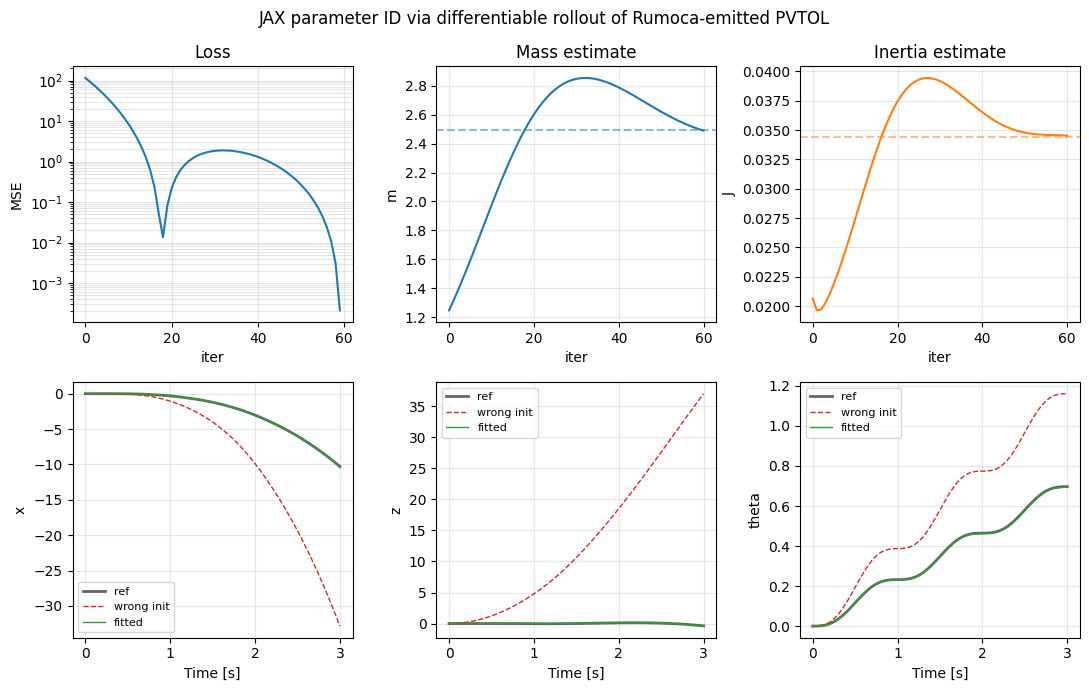

In [6]:
theta_hist = np.array(theta_history)
m_hist = np.exp(theta_hist[:, 0]); J_hist = np.exp(theta_hist[:, 1])

y_init = rollout(jnp.array([m_init, J_init, g]), x0, u_seq, t_grid)
y_fit  = rollout(jnp.array([m_est,  J_est,  g]), x0, u_seq, t_grid)

t = np.asarray(t_grid)
y_ref_np = np.asarray(y_ref); y_init_np = np.asarray(y_init); y_fit_np = np.asarray(y_fit)

fig = plt.figure(figsize=(11, 7))
gs = fig.add_gridspec(2, 3)

ax = fig.add_subplot(gs[0, 0]); ax.semilogy(loss_history); ax.set_xlabel("iter"); ax.set_ylabel("MSE"); ax.set_title("Loss"); ax.grid(alpha=0.3, which="both")
ax = fig.add_subplot(gs[0, 1]); ax.plot(m_hist); ax.axhline(m_true, ls="--", alpha=0.5); ax.set_xlabel("iter"); ax.set_ylabel("m"); ax.set_title("Mass estimate"); ax.grid(alpha=0.3)
ax = fig.add_subplot(gs[0, 2]); ax.plot(J_hist, color="C1"); ax.axhline(J_true, ls="--", color="C1", alpha=0.5); ax.set_xlabel("iter"); ax.set_ylabel("J"); ax.set_title("Inertia estimate"); ax.grid(alpha=0.3)

for i, n in enumerate(("x", "z", "theta")):
    ax = fig.add_subplot(gs[1, i])
    idx = STATE_NAMES.index(n)
    ax.plot(t, y_ref_np[:, idx], "k-", lw=2, alpha=0.6, label="ref")
    ax.plot(t, y_init_np[:, idx], "C3--", lw=1, label="wrong init")
    ax.plot(t, y_fit_np[:, idx], "C2-", lw=1, label="fitted")
    ax.set_xlabel("Time [s]"); ax.set_ylabel(n); ax.legend(fontsize=8); ax.grid(alpha=0.3)

fig.suptitle("JAX parameter ID via differentiable rollout of Rumoca-emitted PVTOL")
fig.tight_layout(); plt.show()